In [14]:
pip install Levenshtein bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 1.5 MB/s  0:00:02 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [Levenshtein]
Note: you may need to restart the kernel to use updated packages.


In [1]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
import os, warnings
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"
os.environ.pop("HF_HUB_ENABLE_HF_TRANSFER", None)
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub")


In [ ]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.8.16: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.559 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

In [5]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 32,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 32,  # Recommended alpha == r at least
    lora_dropout = 0.05,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    target_modules = "all-linear" # Optional now! Can specify a list if needed
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


In [5]:
from datasets import load_dataset
dataset = load_dataset("5CD-AI/Viet-ComputerScience-VQA", split = "train", token = "")

In [6]:
dataset

Dataset({
    features: ['id', 'image', 'description', 'conversations'],
    num_rows: 6899
})

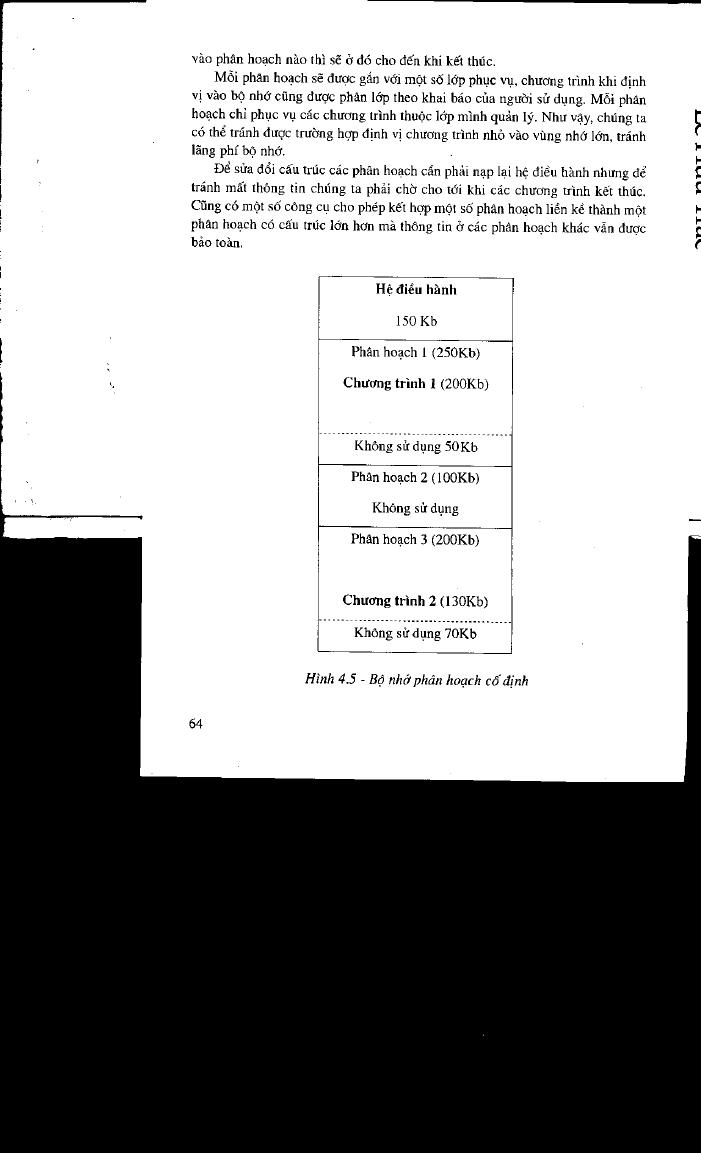

In [ ]:
dataset[2]["image"]

In [9]:
dataset[2]["description"],dataset[2]["conversations"]

('Bức ảnh hiển thị một phần văn bản từ một tài liệu kỹ thuật. Văn bản mô tả cách bố trí bộ nhớ trong hệ điều hành, tập trung vào khái niệm phân hoạch bộ nhớ. Văn bản có các tiêu đề như "Hệ điều hành", "Phân hoạch 1", "Chương trình 1", "Không sử dụng", v.v. Bên cạnh đó, có một sơ đồ minh họa dạng bảng với hai cột. Cột bên trái liệt kê các thành phần như "Hệ điều hành", "Phân hoạch 1", "Chương trình 1", "Không sử dụng", "Phân hoạch 2", "Không sử dụng", "Phân hoạch 3", "Chương trình 2", "Không sử dụng". Cột bên phải thể hiện dung lượng tương ứng với mỗi thành phần, ví dụ: "Hệ điều hành" là 150 Kb, "Phân hoạch 1" là 250 Kb, "Chương trình 1" là 200 Kb, v.v. Phía dưới sơ đồ có dòng chữ "Hình 4.5 - Bộ nhớ phân hoạch cố định".',
 [{'role': 'user', 'content': 'Phân hoạch bộ nhớ là gì?'},
  {'role': 'assistant',
   'content': 'Phân hoạch bộ nhớ là một kỹ thuật quản lý bộ nhớ trong hệ điều hành. Nó chia bộ nhớ khả dụng thành các phần nhỏ hơn, được gọi là "phân hoạch", và gán cho từng chương trình

In [8]:
from torch.utils.data import Dataset

class LazyVQADataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        conversations = sample["conversations"]
        
        first_user_text = f"{sample['description']}\n\n{conversations[0]['content']}"
        
        messages = []
        for i, msg in enumerate(conversations):
            role = msg["role"]
            text_content = first_user_text if i == 0 else msg["content"]
            
            if i == 0 and role == "user":
                messages.append({
                    "role": role,
                    "content": [
                        {"type": "image", "image": sample["image"]},
                        {"type": "text", "text": text_content}
                    ]
                })
            else:
                messages.append({
                    "role": role,
                    "content": [
                        {"type": "text", "text": text_content}
                    ]
                })
                
        return { "messages" : messages }

In [9]:
dataset_split = dataset.train_test_split(test_size = 0.1, seed = 42)
train_dataset = LazyVQADataset(dataset_split["train"])
eval_dataset = LazyVQADataset(dataset_split["test"])


In [ ]:
train_dataset[2]

{'messages': [{'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=700x1012>},
    {'type': 'text',
     'text': 'Bức ảnh mô tả về hệ thống mã hóa và giải mã tín hiệu với nội dung: "Trong một hệ thống m mức sẽ có m-1 mặt phân biệt nhau. Các đường ngang (trong mặt hiển thị mẫu mật) được gắn nhãn +1, 0 và -1 tương ứng với các biên độ được thu lý tưởng. Các đường thẳng đứng (trong mặt hiển thị mẫu mật) cách biệt nhau bởi chu kỳ thời gian T. tương ứng với thời gian quyết định lý tưởng. Các mức quyết định đối với bộ tái tạo tín hiệu được đặc trưng bởi các điểm giao nhau. Các điểm giao nhau với đường thẳng đứng biểu thị thời gian quyết định và các điểm giao nhau với đường ngang biểu thị mức quyết định. Mẫu mật có thể hiển thị đặc tính chất lượng về hình dạng và thời gian đối với một tập âm hoặc sai số nào đó có trong cận bằng đường dây. Trong điều kiện bình thường thì mật mở. Nếu có nhiều hoặc tạp âm thì mật sẽ khép lại. Độ mở

In [11]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Phân hoạch bộ nhớ là gì?"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 0.2, min_p = 0.1)

Phân hoạch bộ nhớ là việc chia nhỏ bộ nhớ chính thành các vùng nhỏ hơn, mỗi vùng được gán cho một chương trình hoặc dữ liệu cụ thể. Điều này giúp quản lý bộ nhớ hiệu quả hơn, tránh tình trạng lãng phí bộ nhớ và đảm bảo các chương trình có thể truy cập vào bộ nhớ một cách độc lập.<|im_end|>


In [11]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [15]:
FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,  # <-- Đã thêm tập Eval ở đây
    args = SFTConfig(
        per_device_train_batch_size = 1,
        per_device_eval_batch_size = 1,
        gradient_accumulation_steps = 16,
        dataloader_num_workers = 2,
        warmup_steps = 25,
        num_train_epochs = 3,
        learning_rate = 1e-4,
        lr_scheduler_type = "cosine",
        logging_first_step = True,
        logging_steps = 10,
        eval_strategy = "steps",   # <-- Kích hoạt đánh giá theo steps
        eval_steps = 50,
        save_strategy = "steps",
        save_steps = 100,
        save_total_limit = 4,
        load_best_model_at_end = True,
        fp16 = False,
        fp16_full_eval = False,
        bf16 = True,
        bf16_full_eval = True,
        eval_accumulation_steps = 10,
        optim = "adamw_8bit",
        output_dir = "outputs3",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 4096,
        packing = False,
        report_to = "none",
        ignore_data_skip = True,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [16]:
from transformers import PrinterCallback

for callback in list(trainer.callback_handler.callbacks):
    if 'Notebook' in callback.__class__.__name__:
        trainer.remove_callback(callback)
        
trainer.add_callback(PrinterCallback())
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,209 | Num Epochs = 3 | Total steps = 1,167
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 102,693,888 of 8,869,817,584 (1.16% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
{'loss': '1.259', 'grad_norm': '0.847', 'learning_rate': '0', 'epoch': '0.002577'}
{'loss': '1.242', 'grad_norm': '0.8322', 'learning_rate': '3.6e-05', 'epoch': '0.02577'}
{'loss': '0.8304', 'grad_norm': '0.1866', 'learning_rate': '7.6e-05', 'epoch': '0.05154'}
{'loss': '0.6804', 'grad_norm': '0.1377', 'learning_rate': '0.0001', 'epoch': '0.07731'}
{'loss': '0.5981', 'grad_norm': '0.1169', 'learning_rate': '9.996e-05', 'epoch': '0.1031'}
{'loss': '0.5705', 'grad_norm': '0.09463', 'learning_rate': '9.989e-05', 'epoch': '0.1288'}
{'eval_loss': '0.5806', 'eval_runtime': '330.2', 'eval_samples_per_second': '2.089', 'eval_steps_per_second': '2.089', 'epoch': '0.1288'}
{'loss': '0.5652', 'grad_norm': '0.09304', 'learning_rate': '9.978e-05', 'epoch': '0.1546'}
{'loss': '0.5333', 'grad_norm': '0.08637', 'learning_rate': '9.963e-05', 'epoch': '0.1804'}
{'loss': '0.

Unsloth: Restored added_tokens_decoder metadata in outputs3/checkpoint-100/tokenizer_config.json.


{'loss': '0.5743', 'grad_norm': '0.1111', 'learning_rate': '9.867e-05', 'epoch': '0.2835'}
{'loss': '0.5359', 'grad_norm': '0.1125', 'learning_rate': '9.834e-05', 'epoch': '0.3092'}
{'loss': '0.526', 'grad_norm': '0.1075', 'learning_rate': '9.797e-05', 'epoch': '0.335'}
{'loss': '0.5199', 'grad_norm': '0.1363', 'learning_rate': '9.756e-05', 'epoch': '0.3608'}
{'loss': '0.5489', 'grad_norm': '0.1865', 'learning_rate': '9.712e-05', 'epoch': '0.3865'}
{'eval_loss': '0.534', 'eval_runtime': '325.3', 'eval_samples_per_second': '2.121', 'eval_steps_per_second': '2.121', 'epoch': '0.3865'}
{'loss': '0.5293', 'grad_norm': '0.1842', 'learning_rate': '9.664e-05', 'epoch': '0.4123'}
{'loss': '0.5209', 'grad_norm': '0.1227', 'learning_rate': '9.613e-05', 'epoch': '0.4381'}
{'loss': '0.5316', 'grad_norm': '0.1272', 'learning_rate': '9.558e-05', 'epoch': '0.4638'}
{'loss': '0.512', 'grad_norm': '0.1268', 'learning_rate': '9.5e-05', 'epoch': '0.4896'}
{'loss': '0.5183', 'grad_norm': '0.1225', 'learni

Unsloth: Restored added_tokens_decoder metadata in outputs3/checkpoint-200/tokenizer_config.json.


...

{'loss': '0.4496', 'grad_norm': '0.1727', 'learning_rate': '4.649e-06', 'epoch': '2.598'}
{'loss': '0.4578', 'grad_norm': '0.1973', 'learning_rate': '4.087e-06', 'epoch': '2.624'}
{'loss': '0.4581', 'grad_norm': '0.1959', 'learning_rate': '3.56e-06', 'epoch': '2.649'}
{'loss': '0.4601', 'grad_norm': '0.1971', 'learning_rate': '3.068e-06', 'epoch': '2.675'}
{'loss': '0.4386', 'grad_norm': '0.2166', 'learning_rate': '2.611e-06', 'epoch': '2.701'}
{'eval_loss': '0.5031', 'eval_runtime': '329.3', 'eval_samples_per_second': '2.096', 'eval_steps_per_second': '2.096', 'epoch': '2.701'}
{'loss': '0.4543', 'grad_norm': '0.191', 'learning_rate': '2.191e-06', 'epoch': '2.727'}
{'loss': '0.4507', 'grad_norm': '0.2118', 'learning_rate': '1.806e-06', 'epoch': '2.752'}
{'loss': '0.4436', 'grad_norm': '0.21', 'learning_rate': '1.458e-06', 'epoch': '2.778'}
{'loss': '0.4324', 'grad_norm': '0.2104', 'learning_rate': '1.147e-06', 'epoch': '2.804'}
{'loss': '0.4601', 'grad_norm': '0.2128', 'learning_rate'

Unsloth: Restored added_tokens_decoder metadata in outputs3/checkpoint-1100/tokenizer_config.json.


{'loss': '0.4331', 'grad_norm': '0.295', 'learning_rate': '6.351e-07', 'epoch': '2.856'}
{'loss': '0.4488', 'grad_norm': '0.2155', 'learning_rate': '4.353e-07', 'epoch': '2.881'}
{'loss': '0.4573', 'grad_norm': '0.4079', 'learning_rate': '2.729e-07', 'epoch': '2.907'}
{'loss': '0.437', 'grad_norm': '0.2026', 'learning_rate': '1.483e-07', 'epoch': '2.933'}
{'loss': '0.4579', 'grad_norm': '0.1766', 'learning_rate': '6.129e-08', 'epoch': '2.959'}
{'eval_loss': '0.503', 'eval_runtime': '332.5', 'eval_samples_per_second': '2.075', 'eval_steps_per_second': '2.075', 'epoch': '2.959'}
{'loss': '0.4502', 'grad_norm': '0.214', 'learning_rate': '1.211e-08', 'epoch': '2.984'}
{'eval_loss': '0.5031', 'eval_runtime': '334.4', 'eval_samples_per_second': '2.063', 'eval_steps_per_second': '2.063', 'epoch': '3'}


Unsloth: Restored added_tokens_decoder metadata in outputs3/checkpoint-1167/tokenizer_config.json.


{'train_runtime': '3.53e+04', 'train_samples_per_second': '0.528', 'train_steps_per_second': '0.033', 'train_loss': '0.4952', 'epoch': '3'}


In [17]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Phân hoạch bộ nhớ là gì?"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 0.2, min_p = 0.1)

Phân hoạch bộ nhớ là việc chia nhỏ bộ nhớ chính của máy tính thành các vùng nhỏ hơn, mỗi vùng được gán cho một chương trình hoặc dữ liệu cụ thể. Việc phân hoạch giúp quản lý bộ nhớ hiệu quả hơn, tránh tình trạng lãng phí bộ nhớ và đảm bảo các chương trình hoạt động trơn tru.<|im_end|>


In [18]:
model.save_pretrained("qwen_lora3")
tokenizer.save_pretrained("qwen_lora3")

Unsloth: Restored added_tokens_decoder metadata in qwen_lora3/tokenizer_config.json.


['qwen_lora3/processor_config.json']

In [ ]:
import torch
import re
import string
import Levenshtein
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter
from tqdm import tqdm
from bert_score import score

# Tải bộ ngắt câu của NLTK
nltk.download('punkt', quiet=True)
smoothie = SmoothingFunction().method1

# --- 1. Hàm chuẩn hóa văn bản ---
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(là|của|như|với)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    def lower(text):
        return str(text).lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def get_text_content(content):
    """Trích xuất chuỗi văn bản từ content (dù là list hay string)."""
    if isinstance(content, str):
        return content
    elif isinstance(content, list):
        texts = []
        for item in content:
            if isinstance(item, dict) and item.get("type") == "text":
                texts.append(item.get("text", ""))
            elif isinstance(item, str):
                texts.append(item)
        return " ".join(texts)
    return str(content)

# --- 2. Các hàm tính toán Metrics ---
def calc_f1(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    
    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)
    if num_same == 0:
        return 0.0
    
    precision = 1.0 * num_same / len(pred_tokens)
    recall = 1.0 * num_same / len(gt_tokens)
    return (2 * precision * recall) / (precision + recall)

def calc_anls(prediction, ground_truth, threshold=0.5):
    pred_norm = normalize_answer(prediction)
    gt_norm = normalize_answer(ground_truth)
    
    if not pred_norm and not gt_norm:
        return 1.0
    if not pred_norm or not gt_norm:
        return 0.0
        
    dist = Levenshtein.distance(pred_norm, gt_norm)
    max_len = max(len(pred_norm), len(gt_norm))
    
    nl = dist / max_len
    return (1.0 - nl) if nl < threshold else 0.0

def calc_bleu4(prediction, ground_truth):
    """Tính điểm BLEU-4 giữa câu dự đoán và đáp án chuẩn."""
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens or not gt_tokens:
        return 1.0 if pred_tokens == gt_tokens else 0.0
    return sentence_bleu([gt_tokens], pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

def calc_rouge_l(prediction, ground_truth):
    """Tính điểm ROUGE-L dựa trên Longest Common Subsequence (LCS)."""
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens or not gt_tokens:
        return 1.0 if pred_tokens == gt_tokens else 0.0
    
    m, n = len(gt_tokens), len(pred_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if gt_tokens[i] == pred_tokens[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i+1][j], dp[i][j+1])
    lcs = dp[m][n]
    if lcs == 0:
        return 0.0
    prec = lcs / n
    rec = lcs / m
    return (2 * prec * rec) / (prec + rec)

# --- 3. ĐÁNH GIÁ TỰ ĐỘNG ĐA LƯỢT (MULTI-TURN) ---
FastVisionModel.for_inference(model)

total_anls = 0.0
total_f1 = 0.0
total_bleu4 = 0.0
total_rouge_l = 0.0
total_evaluated_turns = 0  # Tổng số lượt câu hỏi được đánh giá

all_preds = []
all_gts = []

num_dialogues = min(20, len(eval_dataset))  # Số lượng cuộc hội thoại muốn test
print(f"🔍 Đang đánh giá đa lượt trên {num_dialogues} hội thoại...")

for i in tqdm(range(num_dialogues)):
    sample = eval_dataset[i]
    messages_data = sample["messages"]
    
    # 1. Trích xuất hình ảnh từ câu hỏi đầu tiên
    image = None
    for msg in messages_data:
        if msg["role"] == "user" and isinstance(msg["content"], list):
            for item in msg["content"]:
                if isinstance(item, dict) and item.get("type") == "image":
                    image = item.get("image")
                    break
            if image:
                break
                
    # 2. Duyệt qua từng lượt hỏi - đáp (Cặp User - Assistant)
    for turn_idx in range(0, len(messages_data) - 1, 2):
        user_msg = messages_data[turn_idx]
        asst_msg = messages_data[turn_idx + 1]
        
        if user_msg["role"] != "user" or asst_msg["role"] != "assistant":
            continue
            
        question_text = get_text_content(user_msg["content"])
        gt_answer = get_text_content(asst_msg["content"])
        
        # 3. Xây dựng lịch sử hội thoại cho tới lượt hiện tại
        history_up_to_now = messages_data[:turn_idx + 1]
        formatted_history = []
        
        for idx, msg in enumerate(history_up_to_now):
            role = msg["role"]
            text = get_text_content(msg["content"])
            if role == "user":
                if idx == 0:
                    formatted_history.append({
                        "role": "user",
                        "content": [{"type": "image"}, {"type": "text", "text": text}]
                    })
                else:
                    formatted_history.append({
                        "role": "user",
                        "content": text
                    })
            elif role == "assistant":
                formatted_history.append({
                    "role": "assistant",
                    "content": text
                })
        
        # 4. Tokenize & Model Generate
        input_text = tokenizer.apply_chat_template(formatted_history, add_generation_prompt=True)
        inputs = tokenizer(image, input_text, add_special_tokens=False, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            output_ids = model.generate(
                **inputs, 
                max_new_tokens=256,
                use_cache=True, 
                temperature=0.1, 
                do_sample=False
            )
            
        pred_answer = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        # 5. Lưu kết quả & Tính toán điểm cho lượt này
        all_preds.append(pred_answer)
        all_gts.append(gt_answer)

        anls = calc_anls(pred_answer, gt_answer)
        f1 = calc_f1(pred_answer, gt_answer)
        bleu4 = calc_bleu4(pred_answer, gt_answer)
        rouge_l = calc_rouge_l(pred_answer, gt_answer)

        total_anls += anls
        total_f1 += f1
        total_bleu4 += bleu4
        total_rouge_l += rouge_l
        total_evaluated_turns += 1

        if total_evaluated_turns <= 3:
            print(f"\n--- [Hội thoại {i+1} - Lượt {(turn_idx//2)+1}] ---")
            print(f"❓ Hỏi: {question_text}")
            print(f"✅ Chuẩn: {gt_answer}")
            print(f"🤖 Đoán : {pred_answer}")
            print(f"🎯 ANLS: {anls:.2f} | F1: {f1:.2f} | BLEU-4: {bleu4:.2f} | ROUGE-L: {rouge_l:.2f}")

# --- 4. TÍNH TOÁN BERTSCORE ---
print("\n🧠 Đang tính toán BERTScore trên toàn bộ các lượt...")
P, R, F1_bert = score(all_preds, all_gts, lang="vi", verbose=True) 
avg_bert_f1 = F1_bert.mean().item()

# --- 5. IN KẾT QUẢ TỔNG HỢP TẤT CẢ CÁC LƯỢT ---
print("\n" + "="*55)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ VQA ĐA LƯỢT ({total_evaluated_turns} lượt câu hỏi):")
print(f"🏆 Average ANLS Score       : {total_anls / total_evaluated_turns * 100:.2f}%")
print(f"📈 Average F1-Score         : {total_f1 / total_evaluated_turns * 100:.2f}%")
print(f"🔹 Average BLEU-4           : {total_bleu4 / total_evaluated_turns * 100:.2f}%")
print(f"🔸 Average ROUGE-L          : {total_rouge_l / total_evaluated_turns * 100:.2f}%")
print(f"🤖 Average BERTScore        : {avg_bert_f1 * 100:.2f}%")
print("="*55)


🔍 Đang đánh giá trên 100 mẫu VQA Test...


  1%|          | 1/100 [00:13<22:00, 13.34s/it]


--- Mẫu 1 ---
❓ Câu hỏi: Bức ảnh chụp một phần tài liệu hướng dẫn về lập trình C#.  Phần bên trái hiển thị các đoạn mã lệnh C#  có chú thích chi tiết về các thành phần của Form:  Graphics,  OnPaint,  PrintPage,  Form,  ComponentModel và Components. Phần bên phải hiển thị nội dung  liên quan đến  Phương thức xử lý giao diện đồ họa (GUI)  được trình bày trong phần  'Chương 3-2' của tài liệu, bao gồm: 

- Phương thức cho phép truy cập hiển thị của lớp  'ppView'.
- Phương thức  'MDIChildForm'  và  'InitializeComponent'  gồm các đoạn mã để thiết lập các thuộc tính như  'Location', 'Size', 'AnchorStyles', và  'Controls'.
-  Phương thức 'Dispose'  với chú thích 'Giải phóng tài nguyên'.
-   Chú thích  'Phương thức hỗ trợ cho Designer'  và  'Dung thay đổi phương thức này trong các sửa soạn thảo code của môi trường phát triển'.

Phần dưới cùng của ảnh là một phần của ảnh khác, không liên quan đến nội dung chính của ảnh, hiển thị  tiêu đề 'Xây dựng với các thành phần  Windows Forms' và  'Phát tr

  2%|▏         | 2/100 [00:24<19:39, 12.03s/it]


--- Mẫu 2 ---
❓ Câu hỏi: Bức ảnh là một trang web về lập trình Python, cụ thể là về toán tử định dạng chuỗi trong Python.  Phần đầu trang web có tiêu đề 'Toán tử định dạng chuỗi trong Python' và một đoạn văn ngắn giải thích về toán tử này. Tiếp theo, một ví dụ minh họa cho cách sử dụng toán tử với hàm print() được trình bày. Bên dưới có phần giải thích về kết quả của ví dụ và một bảng liệt kê các biểu tượng có thể sử dụng với toán tử định dạng chuỗi. Cuối cùng, trang web có ghi chú bản quyền, địa chỉ website và số trang.

Toán tử định dạng chuỗi trong Python là gì?
✅ Đáp án chuẩn: Toán tử định dạng chuỗi trong Python là một toán tử cho phép bạn chèn các giá trị vào một chuỗi. Toán tử này được biểu thị bằng dấu '%' và có thể được sử dụng với hàm print() để hiển thị các giá trị được định dạng trên màn hình.
🤖 Mô hình đoán : Toán tử định dạng chuỗi trong Python là một toán tử đặc biệt được sử dụng để định dạng chuỗi. Nó cho phép bạn chèn các giá trị vào chuỗi một cách dễ dàng và linh hoạ

...

calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 0.69 seconds, 145.93 sentences/sec

📊 KẾT QUẢ ĐÁNH GIÁ VQA KHOA HỌC (100 mẫu):
🏆 Average ANLS Score       : 31.73%
📈 Average F1-Score         : 62.78%
🤖 Average BERTScore (Ngữ nghĩa) : 85.30%


In [20]:
from PIL import Image
image1 =  Image.open("test/anh1.png")
image2 = Image.open("test/anh2.png")
image3 =  Image.open("test/anh3.png")
image4 =  Image.open("test/anh4.png")
images = [image1, image2, image3, image4]    # Đưa tất cả ảnh vào 1 list
# 2. Tạo prompt chứa N thẻ {"type": "image"} tương ứng với N ảnh
instruction = "Hãy tìm đường đi từ đỉnh S đến đỉnh G trong ảnh 4 bằng thuật toán dfs nêu rõ từng bước, xét theo thứ tự bảng chữ cái."
messages = [
    {"role": "user",
     "content": [
        {"type": "image"}, # Tương ứng với image1
        {"type": "image"}, # Tương ứng với image2
        {"type": "image"}, # Tương ứng với image3
        {"type": "image"}, # Tương ứng với image4
        {"type": "text", "text": instruction}
    ]}
]
# 3. Apply chat template & Tokenize
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
# LƯU Ý: Truyền danh sách `images` vào tokenizer
inputs = tokenizer(
    images,              # Truyền list chứa cả 2 ảnh
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")
# 4. Generate
FastVisionModel.for_inference(model)
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=1024, temperature=0.1, use_cache=True)
response = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
print(response)

Bắt đầu từ đỉnh S, ta duyệt các đỉnh kề của S theo thứ tự bảng chữ cái: A, B, C, D, G. 
- Từ S, ta duyệt đỉnh A, B, C, D, G. 
- Từ A, ta duyệt đỉnh B, C, D, G. 
- Từ B, ta duyệt đỉnh C, D, G. 
- Từ C, ta duyệt đỉnh D, G. 
- Từ D, ta duyệt đỉnh G. 
- Từ G, ta không có đỉnh kề nào khác, kết thúc thuật toán. 
Đường đi từ S đến G là: S -> A -> B -> C -> D -> G.


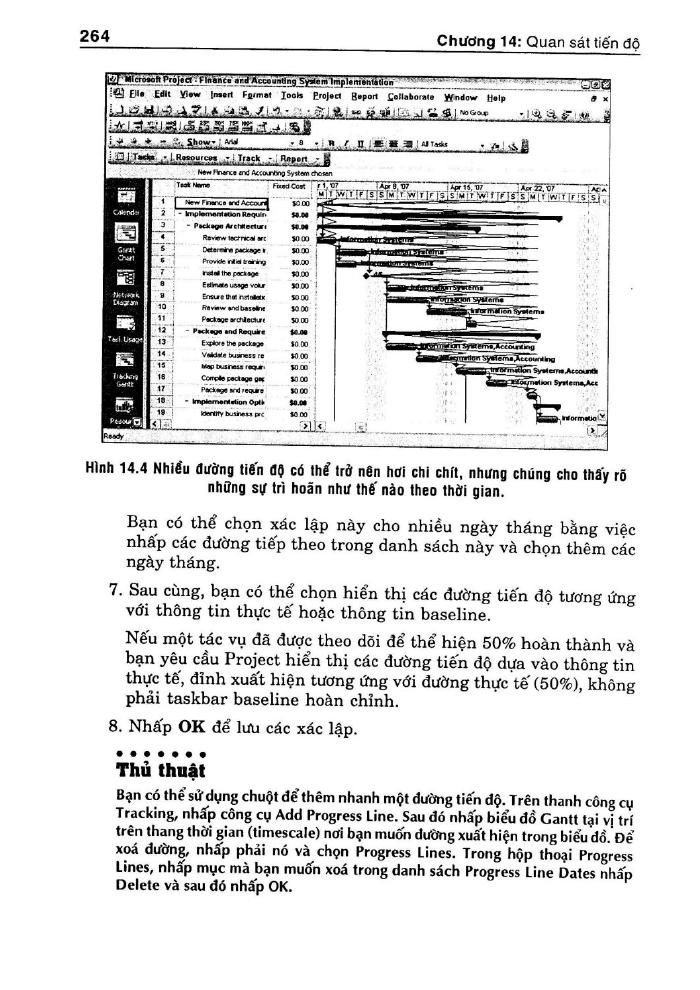

In [14]:
dataset[6879]["image"]

In [16]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[6879]["image"]
instruction = "Tiêu đề của cửa sổ là Microsoft gì?"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 0.1)

Tiêu đề của cửa sổ là Microsoft Project: Finance and Accounting System Implementation.<|im_end|>
